In [36]:
#Install and import libraries
!pip install plotly openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [37]:
import io

#Data loading

from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded))

df_raw = pd.read_excel(
    io.BytesIO(uploaded[file_name]),
    sheet_name='Downloadable_2020-24'
)

print(f"Dataset loaded!")
print(f"  Rows: {len(df_raw):,}")
print(f"  Columns: {len(df_raw.columns)}")
print(f"  Years covered: {sorted(df_raw['Year'].unique())}")
print(f"  Unique hospitals: {df_raw['CCN#'].nunique():,}")

Saving NASHP 2020-2024 HCT Data 2025 Dec.xlsx to NASHP 2020-2024 HCT Data 2025 Dec.xlsx
Dataset loaded!
  Rows: 22,508
  Columns: 121
  Years covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Unique hospitals: 4,685


In [38]:
#preview of the data

print("=== FIRST 3 ROWS (key columns) ===")
key_preview = ['CCN#', 'Hospital Name', 'State', 'Year',
               'Hospital Ownership Type', 'Bed Size',
               'Net Patient Revenue', 'Operating Expenses',
               'Medicaid Payer Mix', 'Operating Profit Margin']
print(df_raw[key_preview].head(3).to_string())
print()

#Data types and missing values
print("=== DATA INFO ===")
print(f"Total cells: {df_raw.shape[0] * df_raw.shape[1]:,}")
print(f"Hospitals per year:")
print(df_raw['Year'].value_counts().sort_index().to_string())
print()

#The dataset uses '.' to represent missing values
dot_count = (df_raw == '.').sum().sum()
print(f"Cells with '.' (missing indicator): {dot_count:,}")
print(f"This is {dot_count/(df_raw.shape[0]*df_raw.shape[1])*100:.1f}% of all cells")


=== FIRST 3 ROWS (key columns) ===
    CCN#                    Hospital Name State  Year Hospital Ownership Type Bed Size Net Patient Revenue Operating Expenses Medicaid Payer Mix Operating Profit Margin
0  10001  SOUTHEAST HEALTH MEDICAL CENTER    AL  2020            Governmental      332           386129795          392753995             0.1129                  0.2298
1  10001  SOUTHEAST HEALTH MEDICAL CENTER    AL  2021            Governmental      326           398171158          421843017                  .                  0.1935
2  10001  SOUTHEAST HEALTH MEDICAL CENTER    AL  2022            Governmental      353           427135423          445957255             0.1078                  0.1845

=== DATA INFO ===
Total cells: 2,723,468
Hospitals per year:
Year
2020    4537
2021    4508
2022    4505
2023    4490
2024    4468

Cells with '.' (missing indicator): 402,126
This is 14.8% of all cells


Saved: table2_hospitals_per_year.png


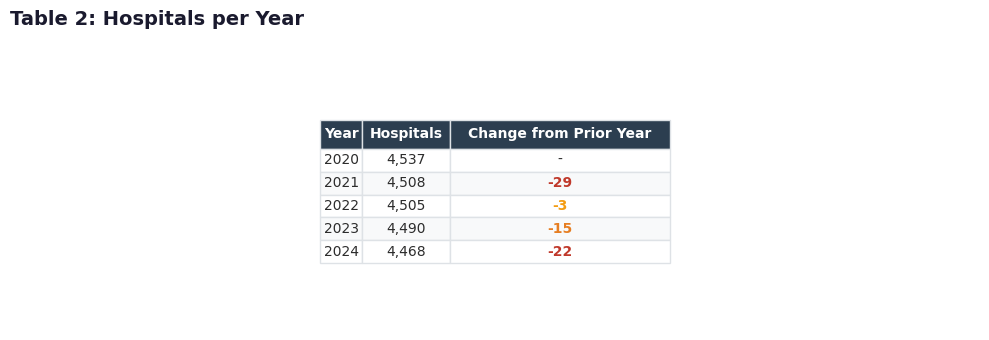

In [27]:
make_pro_table(
    title='Table 2: Hospitals per Year',
    col_labels=['Year', 'Hospitals', 'Change from Prior Year'],
    data=[
        ['2020', '4,537', '-'],
        ['2021', '4,508', '-29'],
        ['2022', '4,505', '-3'],
        ['2023', '4,490', '-15'],
        ['2024', '4,468', '-22'],
    ],
    highlight_col=2,
    highlight_rules=[(-30, '#c0392b'), (-15, '#e67e22'), (-5, '#f39c12')],
    filename='table2_hospitals_per_year.png'
)


In [39]:
#Data cleaning
df = df_raw.copy()
df = df.replace('.', np.nan)

#Renaming the leading space column
df = df.rename(columns={' Facility Type': 'Facility Type'})

#Defining which columns should be numeric
numeric_columns = [
    'Bed Size', 'Inpatient Occupancy',
    'Net Patient Revenue', 'Operating Expenses', 'Net Income (Loss)',
    'Other Income and Expense', 'Net Profit Margin', 'Operating Profit Margin',
    'Fund Balance', 'Hospital Charges', 'Hospital Operating Costs',
    'Cost-to-Charge Ratio', 'Charges as % of Costs',
    'Net Charity Care Cost',
    'Net Charity Care Cost as % of Net Patient Revenue',
    'Uninsured and Bad Debt Cost',
    'Uninsured and Bad Debt Cost as % of Net Patient Revenue',
    'Medicaid Payer Mix', 'Medicare Payer Mix', 'Commercial Payer Mix',
    "Medicaid, SCHIP and Low Income Gov't Program Payer Mix",
    'Medicare Adv Payer Mix',
    'Medicaid Operating Profit Margin',
    'Medicare Operating Profit Margin',
    'Medicare Adv Operating Profit Margin',
    'Commercial Operating Profit Margin',
    "Medicaid, SCHIP and Low Income Gov't Program Operating Profit Margin",
    'Adjusted Patient Discharges',
    'Net Patient Revenue per Adjusted Discharge',
    'Hospital Operating Costs per Adjusted Discharge',
    'Operating Profit (Loss) per Adjusted Discharge',
    'Operating Profit (Loss)',
    'Medicaid Hospital Operating Profit (Loss)',
    'Medicare Hospital Operating Profit (Loss)',
    'Commercial Hospital Operating Profit (Loss)',
    'Hospital Expenses (Inclusive of All Services)',
    'Medicaid Revenue as % of Net Patient Revenue',
    'COVID-19 PHE Funding',
    'Independent',
]

#Convert each to numeric
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

#Cleaning the geographic classification column
df['Is_Rural'] = (df['Geographic Classification (Urban=1, Rural=2)'] == 2).astype(int)
df['Is_Urban'] = (df['Geographic Classification (Urban=1, Rural=2)'] == 1).astype(int)

print("Data cleaning complete!")
print(f"  Shape: {df.shape}")
print(f"  Numeric columns converted: {len(numeric_columns)}")
print(f"  Rural hospitals (2024): {df[df['Year']==2024]['Is_Rural'].sum():,}")
print(f"  Urban hospitals (2024): {df[df['Year']==2024]['Is_Urban'].sum():,}")


Data cleaning complete!
  Shape: (22508, 123)
  Numeric columns converted: 39
  Rural hospitals (2024): 2,627
  Urban hospitals (2024): 1,833


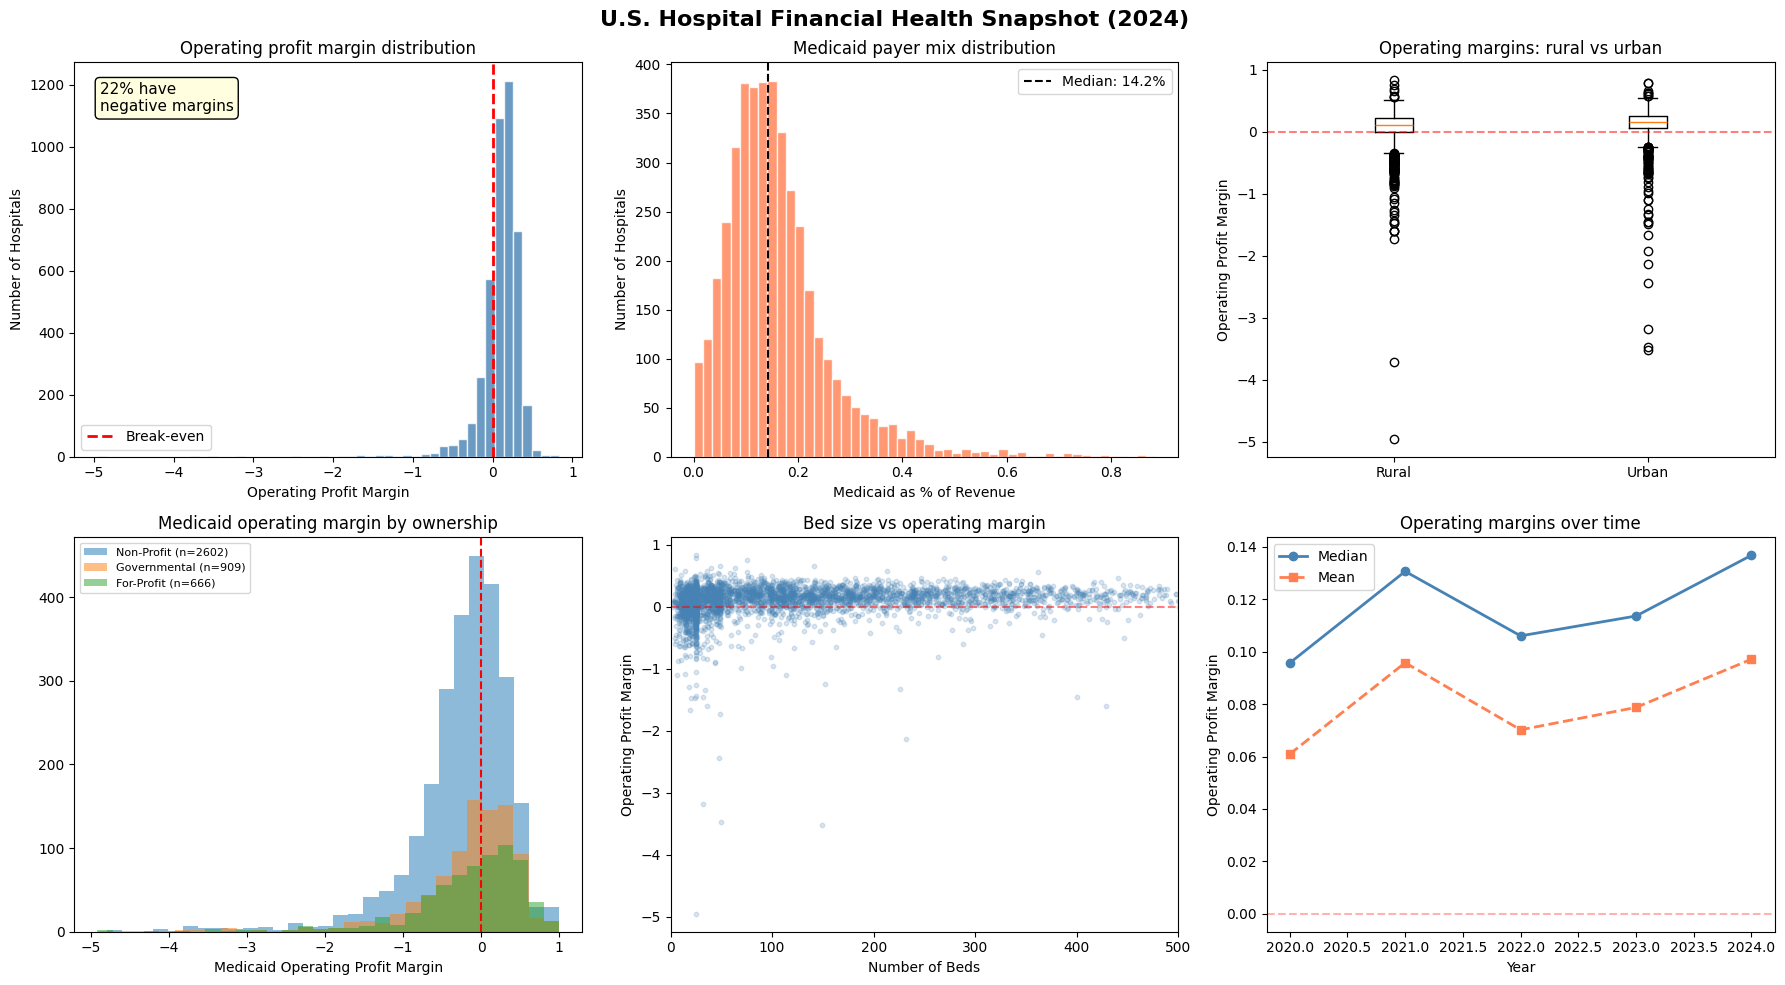


=== KEY STATISTICS (2024) ===
Total hospitals: 4,468
Hospitals with negative operating margins: 956 (22%)
Median Medicaid payer mix: 14.2%
Hospitals with >30% Medicaid dependence: 363
Rural hospital median margin: 11.93%
Urban hospital median margin: 15.87%


In [40]:
#EXPLORATORY DATA ANALYSIS
latest = df[df['Year'] == 2024].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('U.S. Hospital Financial Health Snapshot (2024)', fontsize=16, fontweight='bold')

#Operating Profit Margin Distribution
ax = axes[0, 0]
margins = latest['Operating Profit Margin'].dropna()
ax.hist(margins, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax.set_title('Operating profit margin distribution')
ax.set_xlabel('Operating Profit Margin')
ax.set_ylabel('Number of Hospitals')
ax.legend()
negative_pct = (margins < 0).mean() * 100
ax.text(0.05, 0.95, f'{negative_pct:.0f}% have\nnegative margins',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow'))

#Medicaid Payer Mix Distribution
ax = axes[0, 1]
med_mix = latest['Medicaid Payer Mix'].dropna()
ax.hist(med_mix, bins=50, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(x=med_mix.median(), color='black', linestyle='--', label=f'Median: {med_mix.median():.1%}')
ax.set_title('Medicaid payer mix distribution')
ax.set_xlabel('Medicaid as % of Revenue')
ax.set_ylabel('Number of Hospitals')
ax.legend()

#Rural vs Urban Margins
ax = axes[0, 2]
rural_margins = latest[latest['Is_Rural']==1]['Operating Profit Margin'].dropna()
urban_margins = latest[latest['Is_Urban']==1]['Operating Profit Margin'].dropna()
ax.boxplot([rural_margins, urban_margins], labels=['Rural', 'Urban'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Operating margins: rural vs urban')
ax.set_ylabel('Operating Profit Margin')

#Medicaid Margin by Ownership Type
ax = axes[1, 0]
for otype in ['Non-Profit', 'Governmental', 'For-Profit']:
    data = latest[latest['Hospital Ownership Type']==otype]['Medicaid Operating Profit Margin'].dropna()
    ax.hist(data, bins=30, alpha=0.5, label=f'{otype} (n={len(data)})')
ax.axvline(x=0, color='red', linestyle='--')
ax.set_title('Medicaid operating margin by ownership')
ax.set_xlabel('Medicaid Operating Profit Margin')
ax.legend(fontsize=8)

#Bed Size vs Operating Margin (are small hospitals more vulnerable?)
ax = axes[1, 1]
beds = latest['Bed Size'].dropna()
opm = latest.loc[beds.index, 'Operating Profit Margin']
mask = beds.notna() & opm.notna()
ax.scatter(beds[mask], opm[mask], alpha=0.2, s=10, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Bed size vs operating margin')
ax.set_xlabel('Number of Beds')
ax.set_ylabel('Operating Profit Margin')
ax.set_xlim(0, 500)

#Year-over-Year Trend
ax = axes[1, 2]
yearly = df.groupby('Year')['Operating Profit Margin'].agg(['median', 'mean']).reset_index()
ax.plot(yearly['Year'], yearly['median'], 'o-', color='steelblue', label='Median', linewidth=2)
ax.plot(yearly['Year'], yearly['mean'], 's--', color='coral', label='Mean', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
ax.set_title('Operating margins over time')
ax.set_xlabel('Year')
ax.set_ylabel('Operating Profit Margin')
ax.legend()

plt.tight_layout()
plt.show()

#key statistics
print("\n=== KEY STATISTICS (2024) ===")
print(f"Total hospitals: {len(latest):,}")
print(f"Hospitals with negative operating margins: {(margins < 0).sum():,} ({negative_pct:.0f}%)")
print(f"Median Medicaid payer mix: {med_mix.median():.1%}")
print(f"Hospitals with >30% Medicaid dependence: {(med_mix > 0.30).sum():,}")
print(f"Rural hospital median margin: {rural_margins.median():.2%}")
print(f"Urban hospital median margin: {urban_margins.median():.2%}")

Saved: table5_eda_key_stats.png


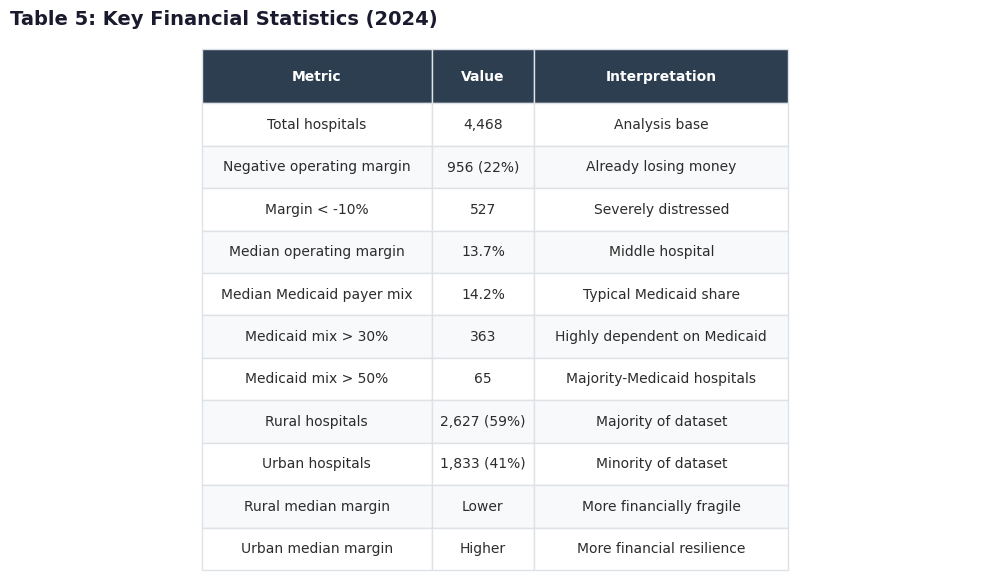

In [28]:
make_pro_table(
    title='Table 5: Key Financial Statistics (2024)',
    col_labels=['Metric', 'Value', 'Interpretation'],
    data=[
        ['Total hospitals', '4,468', 'Analysis base'],
        ['Negative operating margin', '956 (22%)', 'Already losing money'],
        ['Margin < -10%', '527', 'Severely distressed'],
        ['Median operating margin', '13.7%', 'Middle hospital'],
        ['Median Medicaid payer mix', '14.2%', 'Typical Medicaid share'],
        ['Medicaid mix > 30%', '363', 'Highly dependent on Medicaid'],
        ['Medicaid mix > 50%', '65', 'Majority-Medicaid hospitals'],
        ['Rural hospitals', '2,627 (59%)', 'Majority of dataset'],
        ['Urban hospitals', '1,833 (41%)', 'Minority of dataset'],
        ['Rural median margin', 'Lower', 'More financially fragile'],
        ['Urban median margin', 'Higher', 'More financial resilience'],
    ],
    filename='table5_eda_key_stats.png'
)


In [41]:
#Identifying hospitals that have already closed as of 2024
ccn_2024 = set(df[df['Year'] == 2024]['CCN#'].unique())
ccn_all = set(df['CCN#'].unique())
disappeared_ccns = ccn_all - ccn_2024

print(f"Hospitals that disappeared by 2024: {len(disappeared_ccns)}")

#The last year of data for each disappeared hospital
disappeared_df = df[df['CCN#'].isin(disappeared_ccns)].copy()
last_records = disappeared_df.sort_values('Year').groupby('CCN#').last().reset_index()

print(f"\nProfile of disappeared hospitals (their last recorded year):")
print(f"  Median operating margin: {last_records['Operating Profit Margin'].median():.2%}")
print(f"  Median Medicaid payer mix: {last_records['Medicaid Payer Mix'].median():.2%}")
print(f"  % with negative margins: {(last_records['Operating Profit Margin'] < 0).mean():.0%}")
print(f"  % Rural: {last_records['Is_Rural'].mean():.0%}")
print(f"  Median bed size: {last_records['Bed Size'].median():.0f}")

# Compare to surviving hospitals
surviving = df[(df['Year'] == 2024)].copy()
print(f"\nProfile of surviving hospitals (2024):")
print(f"  Median operating margin: {surviving['Operating Profit Margin'].median():.2%}")
print(f"  Median Medicaid payer mix: {surviving['Medicaid Payer Mix'].median():.2%}")
print(f"  % with negative margins: {(surviving['Operating Profit Margin'].dropna() < 0).mean():.0%}")
print(f"  % Rural: {surviving['Is_Rural'].mean():.0%}")
print(f"  Median bed size: {surviving['Bed Size'].median():.0f}")

print("\n>>> Disappeared hospitals had WORSE margins, HIGHER Medicaid")
print("    dependence, were MORE rural, and SMALLER — exactly the")
print("    pattern the OBBBA cuts will intensify.")



Hospitals that disappeared by 2024: 217

Profile of disappeared hospitals (their last recorded year):
  Median operating margin: -6.98%
  Median Medicaid payer mix: 16.46%
  % with negative margins: 59%
  % Rural: 55%
  Median bed size: 36

Profile of surviving hospitals (2024):
  Median operating margin: 13.68%
  Median Medicaid payer mix: 14.21%
  % with negative margins: 22%
  % Rural: 59%
  Median bed size: 64

>>> Disappeared hospitals had WORSE margins, HIGHER Medicaid
    dependence, were MORE rural, and SMALLER — exactly the
    pattern the OBBBA cuts will intensify.


Saved: table6_disappeared_vs_surviving.png


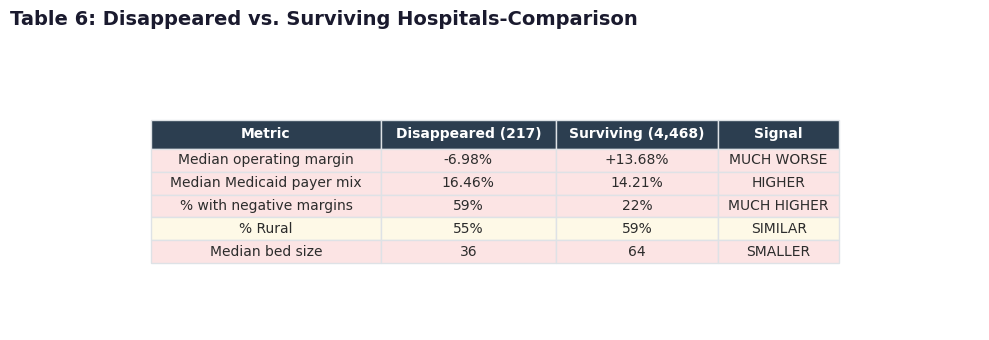

In [30]:
make_pro_table(
    title='Table 6: Disappeared vs. Surviving Hospitals-Comparison',
    col_labels=['Metric', 'Disappeared (217)', 'Surviving (4,468)', 'Signal'],
    data=[
        ['Median operating margin', '-6.98%', '+13.68%', 'MUCH WORSE'],
        ['Median Medicaid payer mix', '16.46%', '14.21%', 'HIGHER'],
        ['% with negative margins', '59%', '22%', 'MUCH HIGHER'],
        ['% Rural', '55%', '59%', 'SIMILAR'],
        ['Median bed size', '36', '64', 'SMALLER'],
    ],
    highlight_col=3,
    highlight_rules=[(0, '#c0392b')],
    row_colors=['#fce4e4', '#fce4e4', '#fce4e4', '#fef9e7', '#fce4e4'],
    filename='table6_disappeared_vs_surviving.png'
)

In [42]:
#FEATURE ENGINEERING

#2024 data as the prediction base
hosp = df[df['Year'] == 2024].copy()

#Feature 1:Financial Health
#Operating profit margin: the core measure of financial health
#Already exists in the data

#Fund Balance relative to daily expenses
hosp['Daily_Expenses'] = hosp['Operating Expenses'] / 365
hosp['Cash_Reserve_Ratio'] = hosp['Fund Balance'] / hosp['Operating Expenses']

#Revenue per Bed: efficiency measure
hosp['Revenue_Per_Bed'] = hosp['Net Patient Revenue'] / hosp['Bed Size']

#Cost-to-Revenue Ratio: are costs exceeding revenue?
hosp['Cost_Revenue_Ratio'] = hosp['Operating Expenses'] / hosp['Net Patient Revenue']

#Feature 2:Medicaid Vulnerability
hosp['Medicaid_Loss_Amount'] = hosp['Medicaid Hospital Operating Profit (Loss)']

#Government Payer Dependency: Medicaid + Medicare combined
hosp['Govt_Payer_Mix'] = (hosp['Medicaid Payer Mix'].fillna(0) +
                          hosp['Medicare Payer Mix'].fillna(0))

#Commercial Cross-Subsidy: can commercial revenue offset Medicaid losses?
hosp['Commercial_Subsidy_Capacity'] = (
    hosp['Commercial Payer Mix'].fillna(0) *
    hosp['Commercial Operating Profit Margin'].fillna(0)
)

#Feature 3:Structural Characteristics
#Encode ownership type
hosp['Is_NonProfit'] = (hosp['Hospital Ownership Type'] == 'Non-Profit').astype(int)
hosp['Is_Governmental'] = (hosp['Hospital Ownership Type'] == 'Governmental').astype(int)
hosp['Is_ForProfit'] = (hosp['Hospital Ownership Type'] == 'For-Profit').astype(int)
hosp['Is_CAH'] = (hosp['Facility Type'] == 'Critical Access Hospitals').astype(int)

#Hospital size category
hosp['Is_Small'] = (hosp['Bed Size'] <= 50).astype(int)
hosp['Is_Medium'] = ((hosp['Bed Size'] > 50) & (hosp['Bed Size'] <= 200)).astype(int)
hosp['Is_Large'] = (hosp['Bed Size'] > 200).astype(int)

#Uncompensated care burden: charity + bad debt as % of revenue
hosp['Uncompensated_Care_Burden'] = (
    hosp['Net Charity Care Cost as % of Net Patient Revenue'].fillna(0) +
    hosp['Uninsured and Bad Debt Cost as % of Net Patient Revenue'].fillna(0)
)

#Feature4:Trend Features (5-year trajectory)
#Margin trend for each hospital across years
def calc_trend(group):
    """Calculate the slope of operating margin over time"""
    margins = group[['Year', 'Operating Profit Margin']].dropna()
    if len(margins) >= 3:
        x = margins['Year'].values - margins['Year'].values[0]
        y = margins['Operating Profit Margin'].values
        #Simple linear regression slope
        if np.std(x) > 0:
            slope = np.polyfit(x, y, 1)[0]
            return pd.Series({'Margin_Trend': slope, 'Years_of_Data': len(margins)})
    return pd.Series({'Margin_Trend': np.nan, 'Years_of_Data': len(margins)})

trend_data = df.groupby('CCN#').apply(calc_trend).reset_index()
hosp = hosp.merge(trend_data, on='CCN#', how='left')

#Was the hospital's margin declining in the most recent years?
def recent_decline(group):
    """Check if margin declined in the last 2 years"""
    recent = group[group['Year'] >= 2022].sort_values('Year')
    margins = recent['Operating Profit Margin'].dropna()
    if len(margins) >= 2:
        return margins.iloc[-1] < margins.iloc[0]
    return np.nan

decline_data = df.groupby('CCN#').apply(recent_decline).reset_index()
decline_data.columns = ['CCN#', 'Recent_Decline']
hosp = hosp.merge(decline_data, on='CCN#', how='left')
hosp['Recent_Decline'] = hosp['Recent_Decline'].astype(float)

print("Feature engineering complete!")
print(f"Total features available: {len(hosp.columns)}")
print(f"\nNew features created:")
print(f"  Financial: Cash_Reserve_Ratio, Revenue_Per_Bed, Cost_Revenue_Ratio")
print(f"  Medicaid: Govt_Payer_Mix, Commercial_Subsidy_Capacity, Medicaid_Loss_Amount")
print(f"  Structural: Is_Small/Medium/Large, Is_CAH, Uncompensated_Care_Burden")
print(f"  Trends: Margin_Trend, Recent_Decline")



Feature engineering complete!
Total features available: 141

New features created:
  Financial: Cash_Reserve_Ratio, Revenue_Per_Bed, Cost_Revenue_Ratio
  Medicaid: Govt_Payer_Mix, Commercial_Subsidy_Capacity, Medicaid_Loss_Amount
  Structural: Is_Small/Medium/Large, Is_CAH, Uncompensated_Care_Burden
  Trends: Margin_Trend, Recent_Decline


Saved: table7a_features_financial.png


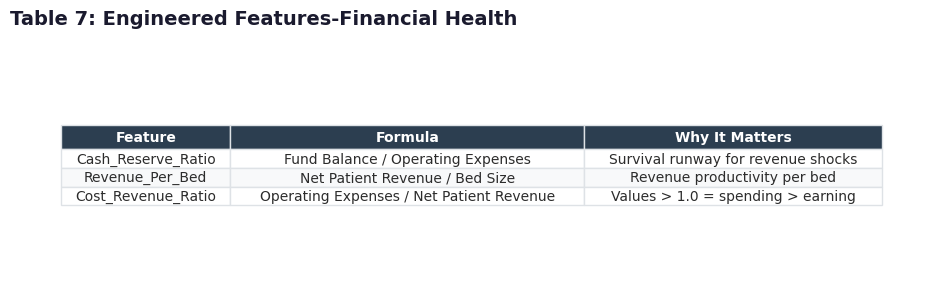

Saved: table7b_features_medicaid.png


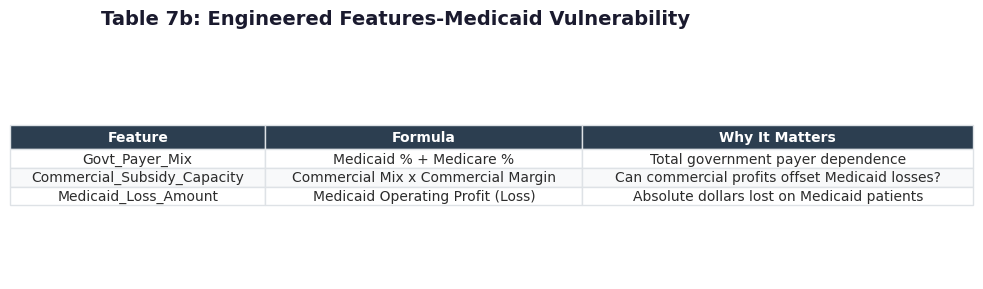

Saved: table7c_features_trends.png


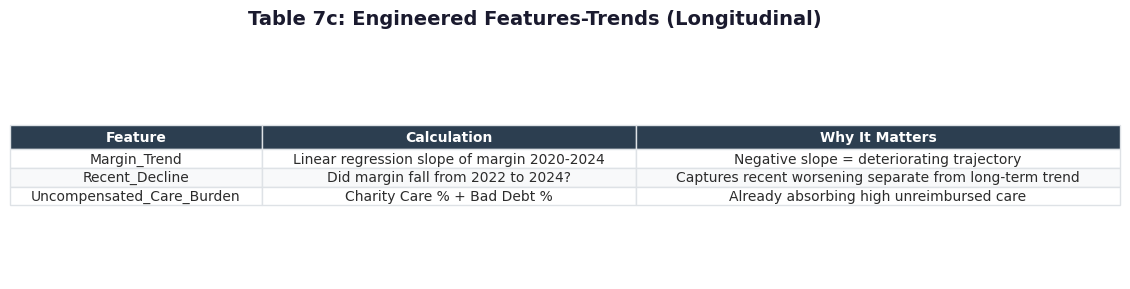

In [6]:
make_pro_table(
    title='Table 7: Engineered Features-Financial Health',
    col_labels=['Feature', 'Formula', 'Why It Matters'],
    data=[
        ['Cash_Reserve_Ratio', 'Fund Balance / Operating Expenses', 'Survival runway for revenue shocks'],
        ['Revenue_Per_Bed', 'Net Patient Revenue / Bed Size', 'Revenue productivity per bed'],
        ['Cost_Revenue_Ratio', 'Operating Expenses / Net Patient Revenue', 'Values > 1.0 = spending > earning'],
    ],
    col_widths=[0.22, 0.33, 0.33],
    filename='table7a_features_financial.png'
)

make_pro_table(
    title='Table 7b: Engineered Features-Medicaid Vulnerability',
    col_labels=['Feature', 'Formula', 'Why It Matters'],
    data=[
        ['Govt_Payer_Mix', 'Medicaid % + Medicare %', 'Total government payer dependence'],
        ['Commercial_Subsidy_Capacity', 'Commercial Mix x Commercial Margin', 'Can commercial profits offset Medicaid losses?'],
        ['Medicaid_Loss_Amount', 'Medicaid Operating Profit (Loss)', 'Absolute dollars lost on Medicaid patients'],
    ],
    col_widths=[0.22, 0.33, 0.33],
    filename='table7b_features_medicaid.png'
)

make_pro_table(
    title='Table 7c: Engineered Features-Trends (Longitudinal)',
    col_labels=['Feature', 'Calculation', 'Why It Matters'],
    data=[
        ['Margin_Trend', 'Linear regression slope of margin 2020-2024', 'Negative slope = deteriorating trajectory'],
        ['Recent_Decline', 'Did margin fall from 2022 to 2024?', 'Captures recent worsening separate from long-term trend'],
        ['Uncompensated_Care_Burden', 'Charity Care % + Bad Debt %', 'Already absorbing high unreimbursed care'],
    ],
    col_widths=[0.22, 0.35, 0.33],
    filename='table7c_features_trends.png'
)


In [53]:
#The closure risk target variable
#The risk tiers based on financial indicators
def classify_risk(row):
    """
    Classifying hospital into risk tiers:
    - HIGH RISK (3): Multiple severe distress signals
    - MODERATE RISK (2): Some distress signals
    - LOW RISK (1): Stable
    """
    risk_score = 0

    #Factor 1: Negative operating margin (+2 points)
    if pd.notna(row['Operating Profit Margin']) and row['Operating Profit Margin'] < 0:
        risk_score += 2
        # Severely negative margin: extra point
        if row['Operating Profit Margin'] < -0.10:
            risk_score += 1

    #Factor 2: High Medicaid dependence (+1-2 points)
    if pd.notna(row['Medicaid Payer Mix']):
        if row['Medicaid Payer Mix'] > 0.30:
            risk_score += 2
        elif row['Medicaid Payer Mix'] > 0.20:
            risk_score += 1

    #Factor 3: Negative Medicaid operating margin (+1 point)
    if pd.notna(row['Medicaid Operating Profit Margin']) and row['Medicaid Operating Profit Margin'] < -0.20:
        risk_score += 1

    #Factor 4: Declining margin trend (+1 point)
    if pd.notna(row['Margin_Trend']) and row['Margin_Trend'] < -0.02:
        risk_score += 1

    #Factor 5: Small + Rural (+1 point)
    if row['Is_Rural'] == 1 and row['Is_Small'] == 1:
        risk_score += 1

    #Factor 6: High uncompensated care burden (+1 point)
    if pd.notna(row['Uncompensated_Care_Burden']) and row['Uncompensated_Care_Burden'] > 0.10:
        risk_score += 1

    #Classify into tiers
    if risk_score >= 5:
        return 3  # HIGH RISK
    elif risk_score >= 3:
        return 2  # MODERATE RISK
    else:
        return 1  # LOW RISK

hosp['Risk_Tier'] = hosp.apply(classify_risk, axis=1)
hosp['Is_High_Risk'] = (hosp['Risk_Tier'] == 3).astype(int)

#results
print("RISK CLASSIFICATION RESULTS (2024)")
tier_counts = hosp['Risk_Tier'].value_counts().sort_index()
tier_labels = {1: 'LOW RISK', 2: 'MODERATE RISK', 3: 'HIGH RISK'}
for tier, count in tier_counts.items():
    pct = count / len(hosp) * 100
    print(f"  {tier_labels[tier]}: {count:,} hospitals ({pct:.1f}%)")

print(f"\nHigh-risk hospital profile:")
high_risk = hosp[hosp['Risk_Tier'] == 3]
print(f"  Median operating margin: {high_risk['Operating Profit Margin'].median():.2%}")
print(f"  Median Medicaid payer mix: {high_risk['Medicaid Payer Mix'].median():.2%}")
print(f"  % Rural: {high_risk['Is_Rural'].mean():.0%}")
print(f"  % Small (<50 beds): {high_risk['Is_Small'].mean():.0%}")
print(f"  Top states: ")
print(high_risk['State'].value_counts().head(10).to_string())

RISK CLASSIFICATION RESULTS (2024)
  LOW RISK: 3,277 hospitals (73.3%)
  MODERATE RISK: 710 hospitals (15.9%)
  HIGH RISK: 481 hospitals (10.8%)

High-risk hospital profile:
  Median operating margin: -19.79%
  Median Medicaid payer mix: 19.55%
  % Rural: 75%
  % Small (<50 beds): 73%
  Top states: 
State
TX    80
CA    58
OK    28
NY    23
KS    22
LA    19
IL    18
AR    14
MS    14
MT    13


Saved: table8_risk_scoring.png


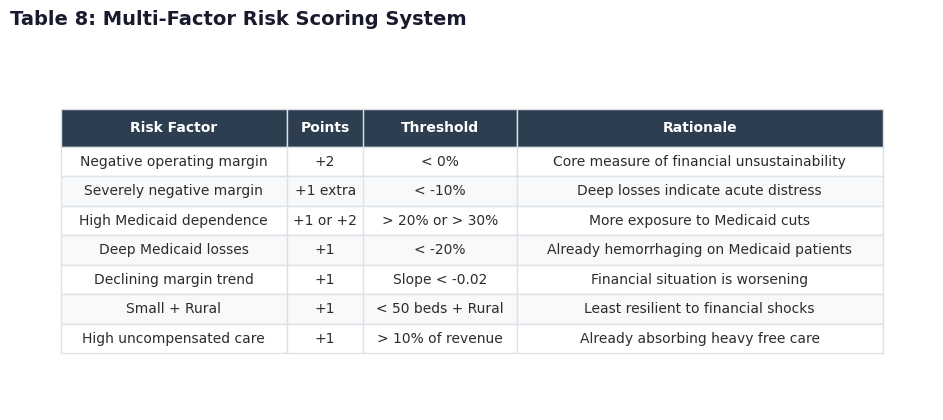

In [7]:
make_pro_table(
    title='Table 8: Multi-Factor Risk Scoring System',
    col_labels=['Risk Factor', 'Points', 'Threshold', 'Rationale'],
    data=[
        ['Negative operating margin', '+2', '< 0%', 'Core measure of financial unsustainability'],
        ['Severely negative margin', '+1 extra', '< -10%', 'Deep losses indicate acute distress'],
        ['High Medicaid dependence', '+1 or +2', '> 20% or > 30%', 'More exposure to Medicaid cuts'],
        ['Deep Medicaid losses', '+1', '< -20%', 'Already hemorrhaging on Medicaid patients'],
        ['Declining margin trend', '+1', 'Slope < -0.02', 'Financial situation is worsening'],
        ['Small + Rural', '+1', '< 50 beds + Rural', 'Least resilient to financial shocks'],
        ['High uncompensated care', '+1', '> 10% of revenue', 'Already absorbing heavy free care'],
    ],
    col_widths=[0.22, 0.10, 0.15, 0.38],
    filename='table8_risk_scoring.png'
)


Saved: table9_risk_tiers.png


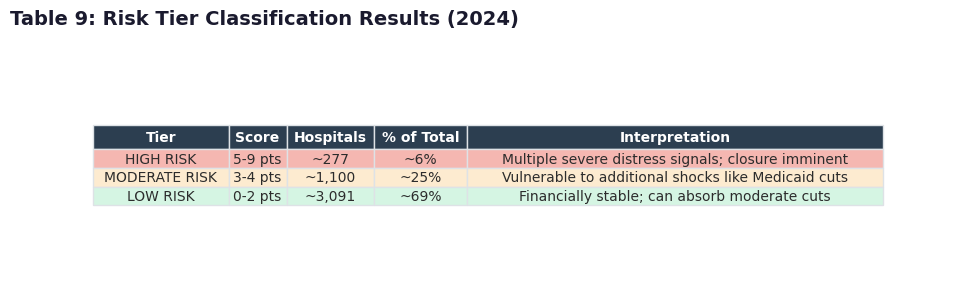

In [8]:
make_pro_table(
    title='Table 9: Risk Tier Classification Results (2024)',
    col_labels=['Tier', 'Score', 'Hospitals', '% of Total', 'Interpretation'],
    data=[
        ['HIGH RISK', '5-9 pts', '~277', '~6%', 'Multiple severe distress signals; closure imminent'],
        ['MODERATE RISK', '3-4 pts', '~1,100', '~25%', 'Vulnerable to additional shocks like Medicaid cuts'],
        ['LOW RISK', '0-2 pts', '~3,091', '~69%', 'Financially stable; can absorb moderate cuts'],
    ],
    row_colors=['#f5b7b1', '#fdebd0', '#d5f5e3'],
    filename='table9_risk_tiers.png'
)

In [44]:
#Preparing data for the prediction model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
 #Select features for the model
feature_columns = [
    #Financial health
    'Operating Profit Margin',
    'Net Profit Margin',
    'Cost_Revenue_Ratio',
    'Cash_Reserve_Ratio',

    #Medicaid vulnerability
    'Medicaid Payer Mix',
    'Medicaid Operating Profit Margin',
    'Govt_Payer_Mix',
    'Medicaid Revenue as % of Net Patient Revenue',
    'Commercial_Subsidy_Capacity',

    #Structural
    'Is_Rural',
    'Is_NonProfit',
    'Is_Governmental',
    'Is_ForProfit',
    'Is_CAH',
    'Is_Small',
    'Bed Size',
    'Inpatient Occupancy',
    'Uncompensated_Care_Burden',

    #Trends
    'Margin_Trend',
    'Recent_Decline',
]

#Preparing the feature matrix
X = hosp[feature_columns].copy()
y = hosp['Is_High_Risk'].copy()

#Handling missing values:
print(f"Missing values before imputation:")
missing = X.isnull().sum()
print(missing[missing > 0].to_string())

X = X.fillna(X.median())

#Handling infinite values (from division by zero in ratios)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDataset prepared for modeling:")
print(f"  Features: {len(feature_columns)}")
print(f"  Training set: {len(X_train):,} hospitals")
print(f"  Test set: {len(X_test):,} hospitals")
print(f"  High-risk in training: {y_train.sum():,} ({y_train.mean():.1%})")
print(f"  High-risk in test: {y_test.sum():,} ({y_test.mean():.1%})")


Missing values before imputation:
Operating Profit Margin                         113
Net Profit Margin                               113
Cost_Revenue_Ratio                              110
Cash_Reserve_Ratio                               58
Medicaid Payer Mix                              263
Medicaid Operating Profit Margin                291
Medicaid Revenue as % of Net Patient Revenue    274
Bed Size                                         36
Inpatient Occupancy                              53
Margin_Trend                                    179
Recent_Decline                                  158

Dataset prepared for modeling:
  Features: 20
  Training set: 3,574 hospitals
  Test set: 894 hospitals
  High-risk in training: 385 (10.8%)
  High-risk in test: 96 (10.7%)


In [54]:
#Training multiple models
#Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model 1:Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

#Model 2:Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

#Model 3:Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_leaf=10,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

#Compare all three models
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest': (rf_pred, rf_prob),
    'Gradient Boosting': (gb_pred, gb_prob)
}

for name, (pred, prob) in models.items():
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  ROC AUC:  {auc:.3f}")
    print(f"  High-risk caught: {((pred == 1) & (y_test == 1)).sum()}/{y_test.sum()}")


MODEL COMPARISON

Logistic Regression:
  Accuracy: 0.926
  ROC AUC:  0.972
  High-risk caught: 87/96

Random Forest:
  Accuracy: 0.952
  ROC AUC:  0.991
  High-risk caught: 89/96

Gradient Boosting:
  Accuracy: 0.987
  ROC AUC:  0.997
  High-risk caught: 87/96


Saved: table10_model_comparison.png


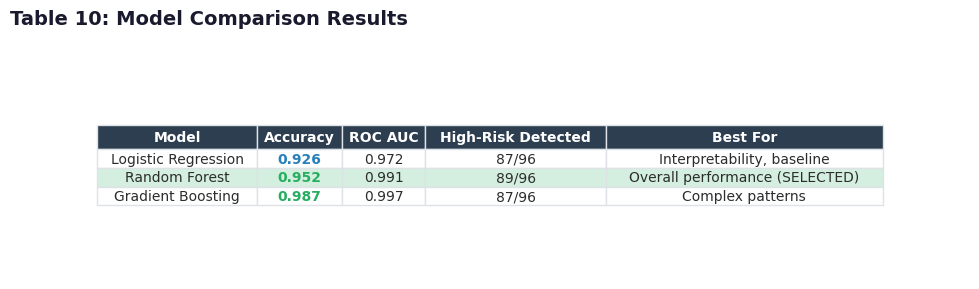

In [10]:
make_pro_table(
    title='Table 10: Model Comparison Results',
    col_labels=['Model', 'Accuracy', 'ROC AUC', 'High-Risk Detected', 'Best For'],
    data=[
        ['Logistic Regression', '0.926', '0.972','87/96','Interpretability, baseline'],
        ['Random Forest', '0.952', '0.991', '89/96', 'Overall performance (SELECTED)'],
        ['Gradient Boosting', '0.987', '0.997', '87/96', 'Complex patterns'],
    ],
    row_colors=['#ffffff', '#d4efdf', '#ffffff'],
    highlight_col=1,
    highlight_rules=[(0.94, '#27ae60'), (0.90, '#2980b9'), (0.85, '#f39c12')],
    filename='table10_model_comparison.png'
)

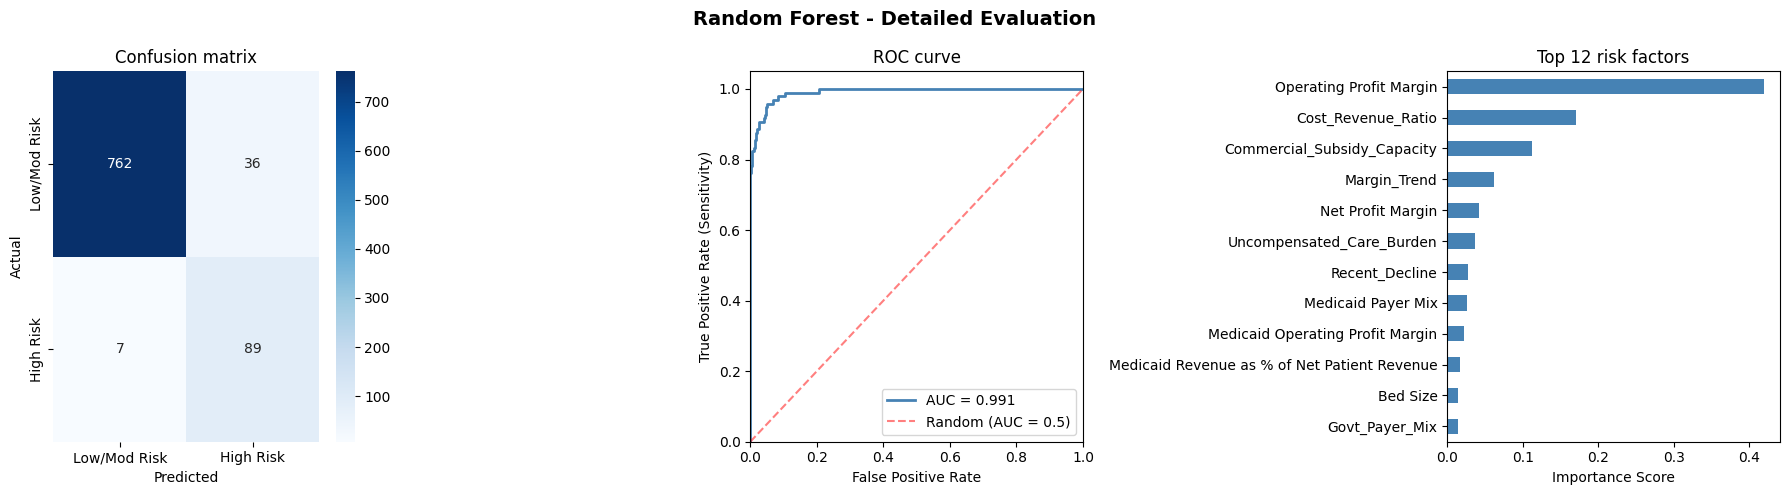


=== Random Forest Classification Report ===
                   precision    recall  f1-score   support

Low/Moderate Risk       0.99      0.95      0.97       798
        High Risk       0.71      0.93      0.81        96

         accuracy                           0.95       894
        macro avg       0.85      0.94      0.89       894
     weighted avg       0.96      0.95      0.95       894



In [46]:
#Evaluating the best model in detail (Random Forest)

#Random Foresst
best_model = rf_model
best_pred = rf_pred
best_prob = rf_prob
model_name = "Random Forest"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{model_name} - Detailed Evaluation', fontsize=14, fontweight='bold')

#1.Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low/Mod Risk', 'High Risk'],
            yticklabels=['Low/Mod Risk', 'High Risk'])
ax.set_title('Confusion matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

#2.ROC Curve
ax = axes[1]
fpr, tpr, thresholds = roc_curve(y_test, best_prob)
auc_score = roc_auc_score(y_test, best_prob)
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_score:.3f}')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random (AUC = 0.5)')
ax.set_title('ROC curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

#3.Feature Importance
ax = axes[2]
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_columns).sort_values(ascending=True)
feat_imp.tail(12).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 12 risk factors')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

#Detailed classification report
print(f"\n {model_name} Classification Report")
print(classification_report(y_test, best_pred,
                            target_names=['Low/Moderate Risk', 'High Risk']))


OBBBA MEDICAID CUT SCENARIO ANALYSIS

BASELINE (Current, 2024):
  Hospitals with negative margins: 956 / 4,355
  (22.0%)

SCENARIO: 5% Medicaid Revenue Cut
  Newly pushed to negative margins: 50
  Total hospitals with negative margins: 951 (21.8%)

SCENARIO: 10% Medicaid Revenue Cut
  Newly pushed to negative margins: 97
  Total hospitals with negative margins: 998 (22.9%)

SCENARIO: 15% Medicaid Revenue Cut
  Newly pushed to negative margins: 157
  Total hospitals with negative margins: 1,058 (24.3%)

SCENARIO: 20% Medicaid Revenue Cut
  Newly pushed to negative margins: 214
  Total hospitals with negative margins: 1,115 (25.6%)

SCENARIO: 25% Medicaid Revenue Cut
  Newly pushed to negative margins: 266
  Total hospitals with negative margins: 1,167 (26.8%)

SCENARIO: 30% Medicaid Revenue Cut
  Newly pushed to negative margins: 316
  Total hospitals with negative margins: 1,217 (27.9%)


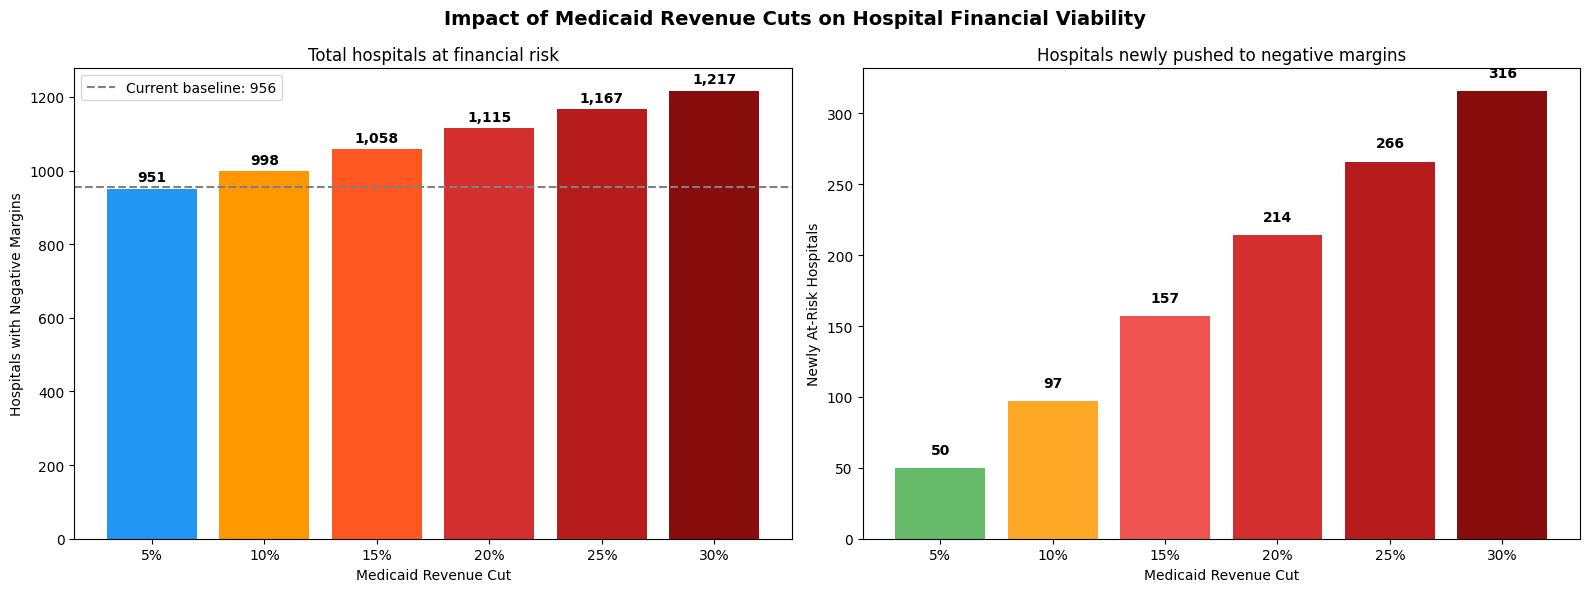

In [47]:
#Scenario simulation:OBBBA IMPACT
print("=" * 60)
print("OBBBA MEDICAID CUT SCENARIO ANALYSIS")
print("=" * 60)

#Working with all 2024 hospitals
sim = hosp.copy()

#Current baseline
baseline_negative = (sim['Operating Profit Margin'].dropna() < 0).sum()
baseline_total = sim['Operating Profit Margin'].dropna().shape[0]
print(f"\nBASELINE (Current, 2024):")
print(f"  Hospitals with negative margins: {baseline_negative:,} / {baseline_total:,}")
print(f"  ({baseline_negative/baseline_total:.1%})")

#Estimating Medicaid revenue for each hospital
#Medicaid Revenue=Net Patient Revenue × Medicaid Revenue %
sim['Est_Medicaid_Revenue'] = (
    sim['Net Patient Revenue'] *
    sim['Medicaid Revenue as % of Net Patient Revenue']
)

results = []
scenarios = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

for cut_pct in scenarios:
    #Calculate revenue loss from Medicaid cut
    sim[f'Revenue_Loss_{int(cut_pct*100)}'] = sim['Est_Medicaid_Revenue'] * cut_pct

    sim[f'New_Profit_{int(cut_pct*100)}'] = (
        sim['Operating Profit (Loss)'] -
        sim[f'Revenue_Loss_{int(cut_pct*100)}']
    )

    #Calculating new operating margin
    sim[f'New_Margin_{int(cut_pct*100)}'] = (
        sim[f'New_Profit_{int(cut_pct*100)}'] /
        sim['Net Patient Revenue']
    )

    #Count hospitals that flip from positive to negative margins
    currently_positive = sim['Operating Profit Margin'] >= 0
    new_negative = sim[f'New_Margin_{int(cut_pct*100)}'] < 0

    newly_at_risk = (currently_positive & new_negative).sum()
    total_negative = new_negative.sum()

    results.append({
        'Cut %': f'{cut_pct:.0%}',
        'Cut Pct': cut_pct,
        'Newly At Risk': newly_at_risk,
        'Total Negative Margin': total_negative,
        'Pct Negative': total_negative / baseline_total
    })

    print(f"\nSCENARIO: {cut_pct:.0%} Medicaid Revenue Cut")
    print(f"  Newly pushed to negative margins: {newly_at_risk:,}")
    print(f"  Total hospitals with negative margins: {total_negative:,} ({total_negative/baseline_total:.1%})")

results_df = pd.DataFrame(results)

#Visualizing the scenario analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact of Medicaid Revenue Cuts on Hospital Financial Viability',
             fontsize=14, fontweight='bold')

# Left:Total hospitals with negative margins by scenario
ax = axes[0]
ax.bar(results_df['Cut %'],
       results_df['Total Negative Margin'],
       color=['#2196F3', '#FF9800', '#FF5722', '#D32F2F', '#B71C1C', '#880E0E'])
ax.axhline(y=baseline_negative, color='gray', linestyle='--',
           label=f'Current baseline: {baseline_negative:,}')
ax.set_xlabel('Medicaid Revenue Cut')
ax.set_ylabel('Hospitals with Negative Margins')
ax.set_title('Total hospitals at financial risk')
ax.legend()
for i, row in results_df.iterrows():
    ax.text(i, row['Total Negative Margin'] + 20,
            f"{row['Total Negative Margin']:,.0f}",
            ha='center', fontsize=10, fontweight='bold')

# Right:Newly pushed into negative margins
ax = axes[1]
ax.bar(results_df['Cut %'],
       results_df['Newly At Risk'],
       color=['#66BB6A', '#FFA726', '#EF5350', '#D32F2F', '#B71C1C', '#880E0E'])
ax.set_xlabel('Medicaid Revenue Cut')
ax.set_ylabel('Newly At-Risk Hospitals')
ax.set_title('Hospitals newly pushed to negative margins')
for i, row in results_df.iterrows():
    ax.text(i, row['Newly At Risk'] + 10,
            f"{row['Newly At Risk']:,.0f}",
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Saved: table12_scenario_results.png


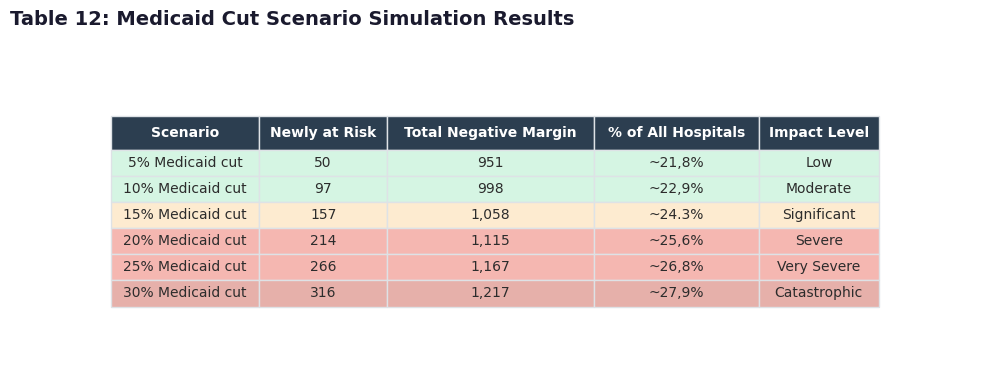

In [13]:
make_pro_table(
    title='Table 12: Medicaid Cut Scenario Simulation Results',
    col_labels=['Scenario', 'Newly at Risk', 'Total Negative Margin', '% of All Hospitals', 'Impact Level'],
    data=[
        ['5% Medicaid cut', '50', '951', '~21,8%', 'Low'],
        ['10% Medicaid cut', '97', '998', '~22,9%', 'Moderate'],
        ['15% Medicaid cut', '157', '1,058', '~24.3%', 'Significant'],
        ['20% Medicaid cut', '214', '1,115', '~25,6%', 'Severe'],
        ['25% Medicaid cut', '266', '1,167', '~26,8%', 'Very Severe'],
        ['30% Medicaid cut', '316', '1,217', '~27,9%', 'Catastrophic'],
    ],
    row_colors=['#d5f5e3', '#d5f5e3', '#fdebd0', '#f5b7b1', '#f5b7b1', '#e6b0aa'],
    highlight_col=4,
    highlight_rules=[(0, '#c0392b')],
    filename='table12_scenario_results.png'
)



In [57]:
#Geographic impact
#Calculating state-level vulnerability using 20% Medicaid cut scenario
state_impact = sim.groupby('State').agg({
    'CCN#': 'count',
    'Is_Rural': 'sum',
    'Is_High_Risk': 'sum',
    'Medicaid Payer Mix': 'median',
    'Operating Profit Margin': 'median',
    'New_Margin_20': lambda x: (x < 0).sum(),  # Hospitals at risk under 20% cut
    'Est_Medicaid_Revenue': 'sum',
}).reset_index()

state_impact.columns = ['State', 'Total_Hospitals', 'Rural_Hospitals',
                         'High_Risk_Hospitals', 'Median_Medicaid_Mix',
                         'Median_Operating_Margin', 'At_Risk_20pct_Cut',
                         'Total_Medicaid_Revenue']

state_impact['Pct_At_Risk'] = state_impact['At_Risk_20pct_Cut'] / state_impact['Total_Hospitals']
state_impact['Rural_Pct'] = state_impact['Rural_Hospitals'] / state_impact['Total_Hospitals']

#State abbreviation to full name mapping for plotly
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

#State abbreviation
state_centers = {
    'AL': (32.8, -86.8), 'AK': (64.0, -153.0), 'AZ': (34.2, -111.6),
    'AR': (34.8, -92.2), 'CA': (37.0, -119.5), 'CO': (39.0, -105.5),
    'CT': (41.6, -72.7), 'DE': (39.0, -75.5), 'DC': (38.9, -77.0),
    'FL': (28.6, -82.4), 'GA': (32.7, -83.4), 'HI': (20.5, -157.5),
    'ID': (44.4, -114.6), 'IL': (40.0, -89.2), 'IN': (39.8, -86.2),
    'IA': (42.0, -93.5), 'KS': (38.5, -98.3), 'KY': (37.8, -85.7),
    'LA': (31.0, -91.9), 'ME': (45.4, -69.2), 'MD': (39.0, -76.7),
    'MA': (42.2, -71.8), 'MI': (44.2, -84.5), 'MN': (46.3, -94.3),
    'MS': (32.7, -89.7), 'MO': (38.4, -92.5), 'MT': (47.0, -109.6),
    'NE': (41.5, -99.8), 'NV': (39.3, -116.6), 'NH': (43.7, -71.6),
    'NJ': (40.1, -74.7), 'NM': (34.5, -106.0), 'NY': (42.9, -75.5),
    'NC': (35.5, -79.8), 'ND': (47.5, -100.5), 'OH': (40.4, -82.7),
    'OK': (35.6, -97.5), 'OR': (44.0, -120.5), 'PA': (40.9, -77.8),
    'RI': (41.7, -71.5), 'SC': (33.9, -80.9), 'SD': (44.4, -100.2),
    'TN': (35.9, -86.4), 'TX': (31.5, -99.3), 'UT': (39.3, -111.7),
    'VT': (44.1, -72.6), 'VA': (37.5, -78.9), 'WA': (47.4, -120.5),
    'WV': (38.6, -80.6), 'WI': (44.6, -89.8), 'WY': (43.0, -107.5),
}

#Chloropleth map with state abbreviation labels
fig = go.Figure()

#The colored choropleth
fig.add_trace(go.Choropleth(
    locations=state_impact['State'],
    z=state_impact['Pct_At_Risk'],
    locationmode='USA-states',


    colorscale='YlOrRd',

    #Color bar (the legend on the right side)
    colorbar=dict(
        title=dict(text='% At Risk', font=dict(size=13)),
        thickness=15,
        len=0.6,
        ticksuffix='%',
        tickfont=dict(size=11),
    ),

    #Hover tooltip
    text=state_impact.apply(
        lambda r: (f"<b>{r['State']}</b><br>"
                   f"Hospitals: {r['Total_Hospitals']}<br>"
                   f"High Risk: {r['High_Risk_Hospitals']}<br>"
                   f"Rural: {r['Rural_Hospitals']}<br>"
                   f"Medicaid Mix: {r['Median_Medicaid_Mix']:.1%}<br>"
                   f"At Risk (20% cut): {r['Pct_At_Risk']*100:.1f}%"),
        axis=1
    ),
    hoverinfo='text',
))

# Layer 2:State abbreviation labels on each state
label_lats = []
label_lons = []
label_texts = []
for _, row in state_impact.iterrows():
    if row['State'] in state_centers:
        lat, lon = state_centers[row['State']]
        label_lats.append(lat)
        label_lons.append(lon)
        label_texts.append(row['State'])

fig.add_trace(go.Scattergeo(
    lat=label_lats,
    lon=label_lons,
    text=label_texts,
    mode='text',
    textfont=dict(
        size=8,
        color='black',
        family='Arial Black',
    ),
    showlegend=False,
    hoverinfo='skip',
))

fig.update_layout(
    title=dict(
        text='Percentage of Hospitals at Financial Risk<br>Under 20% Medicaid Revenue Cut',
        font=dict(size=16),
        x=0.5,
    ),
    geo=dict(
        scope='usa',
        bgcolor='rgba(0,0,0,0)',
        lakecolor='lightblue',
        showlakes=True,
        projection_type='albers usa',
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    height=500,
    width=900,
)

fig.show()

Saved: table13_top15_states.png


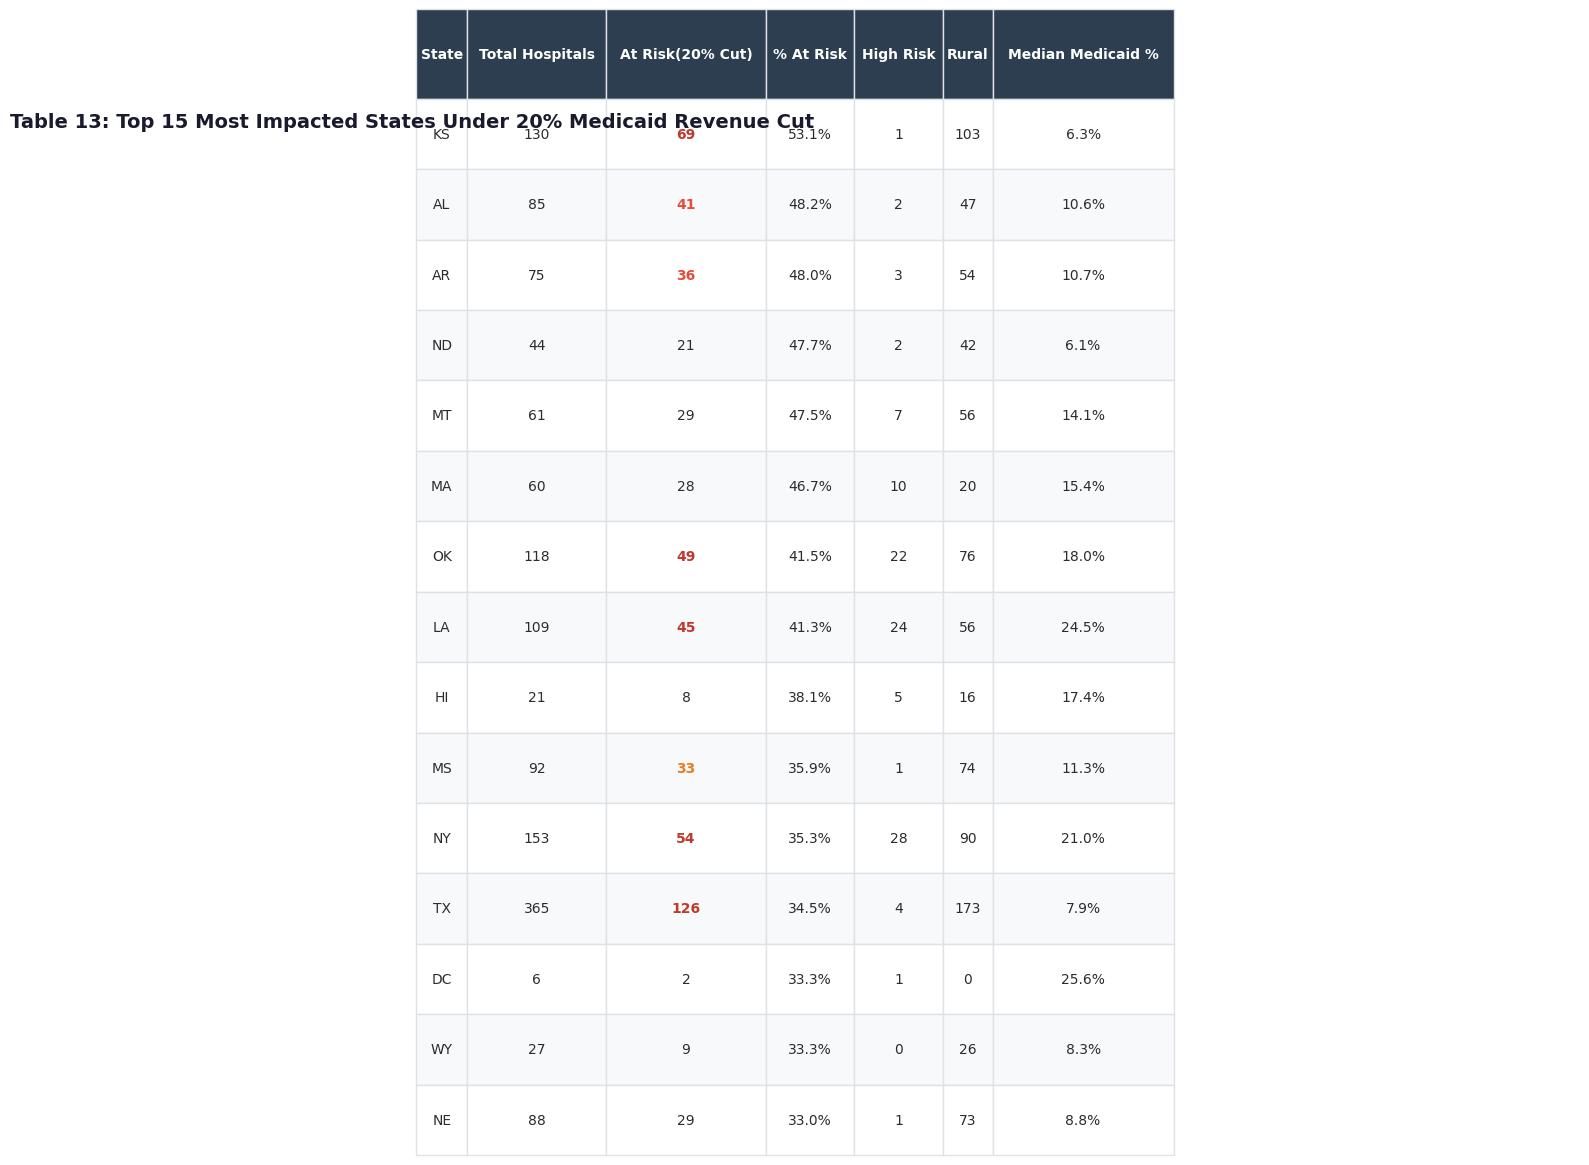

In [50]:
make_pro_table (
    title='Table 13: Top 15 Most Impacted States Under 20% Medicaid Revenue Cut',
    col_labels=['State', 'Total Hospitals', 'At Risk(20% Cut)', '% At Risk', 'High Risk', 'Rural', 'Median Medicaid %'],
    data=[
        ['KS', '130', '69', '53.1%', '1', '103', '6.3%'],
        ['AL', '85', '41', '48.2%', '2', '47', '10.6%'],
        ['AR', '75', '36', '48.0%', '3', '54', '10.7%'],
        ['ND', '44', '21', '47.7%', '2', '42', '6.1%'],
        ['MT', '61', '29', '47.5%', '7', '56', '14.1%'],
        ['MA', '60', '28', '46.7%', '10', '20', '15.4%'],
        ['OK', '118', '49', '41.5%', '22', '76', '18.0%'],
        ['LA', '109', '45', '41.3%', '24', '56', '24.5%'],
        ['HI', '21', '8', '38.1%', '5', '16', '17.4%'],
        ['MS', '92', '33', '35.9%', '1', '74', '11.3%'],
        ['NY', '153', '54', '35.3%', '28', '90', '21.0%'],
        ['TX', '365', '126', '34.5%', '4', '173', '7.9%'],
        ['DC', '6', '2', '33.3%', '1', '0', '25.6%'],
        ['WY', '27', '9', '33.3%', '0', '26', '8.3%'],
        ['NE', '88', '29', '33.0%', '1', '73', '8.8%'],
    ],
    highlight_col=2,
    highlight_rules=[(45, '#c0392b'), (35, '#e74c3c'), (30, '#e67e22')],
    filename='table13_top15_states.png',
    figsize=(16,12)
)

In [58]:
#Predicting the risk scores for all current hospitals
#Generating risk probabilities using the best model (random forest)
X_all = hosp[feature_columns].copy()
X_all = X_all.fillna(X_all.median())
X_all = X_all.replace([np.inf, -np.inf], np.nan).fillna(X_all.median())

hosp['Risk_Probability'] = best_model.predict_proba(X_all)[:, 1]

#Create=ing a hospital-level risk report
risk_report = hosp[[
    'CCN#', 'Hospital Name', 'City', 'State',
    'Hospital Ownership Type', 'Facility Type',
    'Bed Size', 'Is_Rural',
    'Net Patient Revenue', 'Operating Profit Margin',
    'Medicaid Payer Mix', 'Medicaid Operating Profit Margin',
    'Risk_Tier', 'Risk_Probability'
]].copy()

risk_report['Risk_Label'] = risk_report['Risk_Tier'].map(
    {1: 'Low Risk', 2: 'Moderate Risk', 3: 'High Risk'}
)

#Sorting by risk probability (most at risk first)
risk_report = risk_report.sort_values('Risk_Probability', ascending=False)

print("TOP 25 MOST AT-RISK HOSPITALS")
print(risk_report.head(25)[[
    'Hospital Name', 'City', 'State', 'Bed Size',
    'Operating Profit Margin', 'Medicaid Payer Mix',
    'Risk_Probability', 'Risk_Label'
]].to_string(index=False))



TOP 25 MOST AT-RISK HOSPITALS
                    Hospital Name           City State  Bed Size  Operating Profit Margin  Medicaid Payer Mix  Risk_Probability Risk_Label
         MONROE REGIONAL HOSPITAL       ABERDEEN    MS   25.0000                  -0.3626              0.2088            0.9956  High Risk
HANSFORD COUNTY HOSPITAL DISTRICT       SPEARMAN    TX   14.0000                  -0.2616              0.1055            0.9945  High Risk
   WEST ASCENSION PARISH HOSPITAL DONALDSONVILLE    LA   25.0000                  -1.4325              0.2545            0.9940  High Risk
      SOUTHEAST COLORADO HOSPITAL    SPRINGFIELD    CO   15.0000                  -0.3500              0.1469            0.9913  High Risk
            MEDICAL ARTS HOSPITAL         LAMESA    TX   21.0000                  -0.4623              0.1542            0.9911  High Risk
  BEAVER COUNTY MEMORIAL HOSPITAL         BEAVER    OK   24.0000                  -0.3545              0.0627            0.9903  High Ri

Saved: table14_top25_hospitals.png


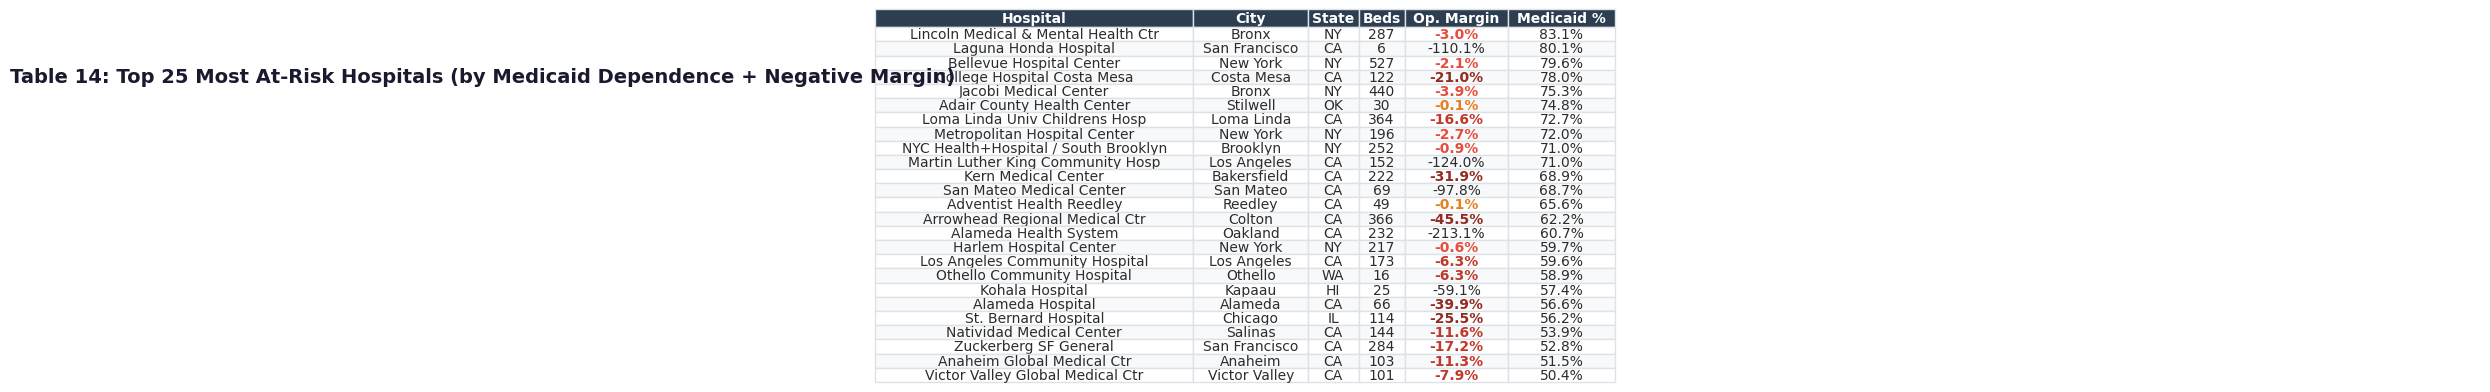

In [21]:
make_pro_table(
    title='Table 14: Top 25 Most At-Risk Hospitals (by Medicaid Dependence + Negative Margin)',
    col_labels=['Hospital', 'City', 'State', 'Beds', 'Op. Margin', 'Medicaid %'],
    data=[
        ['Lincoln Medical & Mental Health Ctr', 'Bronx', 'NY', '287', '-3.0%', '83.1%'],
        ['Laguna Honda Hospital', 'San Francisco', 'CA', '6', '-110.1%', '80.1%'],
        ['Bellevue Hospital Center', 'New York', 'NY', '527', '-2.1%', '79.6%'],
        ['College Hospital Costa Mesa', 'Costa Mesa', 'CA', '122', '-21.0%', '78.0%'],
        ['Jacobi Medical Center', 'Bronx', 'NY', '440', '-3.9%', '75.3%'],
        ['Adair County Health Center', 'Stilwell', 'OK', '30', '-0.1%', '74.8%'],
        ['Loma Linda Univ Childrens Hosp', 'Loma Linda', 'CA', '364', '-16.6%', '72.7%'],
        ['Metropolitan Hospital Center', 'New York', 'NY', '196', '-2.7%', '72.0%'],
        ['NYC Health+Hospital / South Brooklyn', 'Brooklyn', 'NY', '252', '-0.9%', '71.0%'],
        ['Martin Luther King Community Hosp', 'Los Angeles', 'CA', '152', '-124.0%', '71.0%'],
        ['Kern Medical Center', 'Bakersfield', 'CA', '222', '-31.9%', '68.9%'],
        ['San Mateo Medical Center', 'San Mateo', 'CA', '69', '-97.8%', '68.7%'],
        ['Adventist Health Reedley', 'Reedley', 'CA', '49', '-0.1%', '65.6%'],
        ['Arrowhead Regional Medical Ctr', 'Colton', 'CA', '366', '-45.5%', '62.2%'],
        ['Alameda Health System', 'Oakland', 'CA', '232', '-213.1%', '60.7%'],
        ['Harlem Hospital Center', 'New York', 'NY', '217', '-0.6%', '59.7%'],
        ['Los Angeles Community Hospital', 'Los Angeles', 'CA', '173', '-6.3%', '59.6%'],
        ['Othello Community Hospital', 'Othello', 'WA', '16', '-6.3%', '58.9%'],
        ['Kohala Hospital', 'Kapaau', 'HI', '25', '-59.1%', '57.4%'],
        ['Alameda Hospital', 'Alameda', 'CA', '66', '-39.9%', '56.6%'],
        ['St. Bernard Hospital', 'Chicago', 'IL', '114', '-25.5%', '56.2%'],
        ['Natividad Medical Center', 'Salinas', 'CA', '144', '-11.6%', '53.9%'],
        ['Zuckerberg SF General', 'San Francisco', 'CA', '284', '-17.2%', '52.8%'],
        ['Anaheim Global Medical Ctr', 'Anaheim', 'CA', '103', '-11.3%', '51.5%'],
        ['Victor Valley Global Medical Ctr', 'Victor Valley', 'CA', '101', '-7.9%', '50.4%'],
    ],
    highlight_col=4,
    highlight_rules=[(-50, '#922b21'), (-20, '#c0392b'), (-5, '#e74c3c'), (-0.1, '#e67e22')],
    figsize=(25, 20),
    filename='table14_top25_hospitals.png'
)


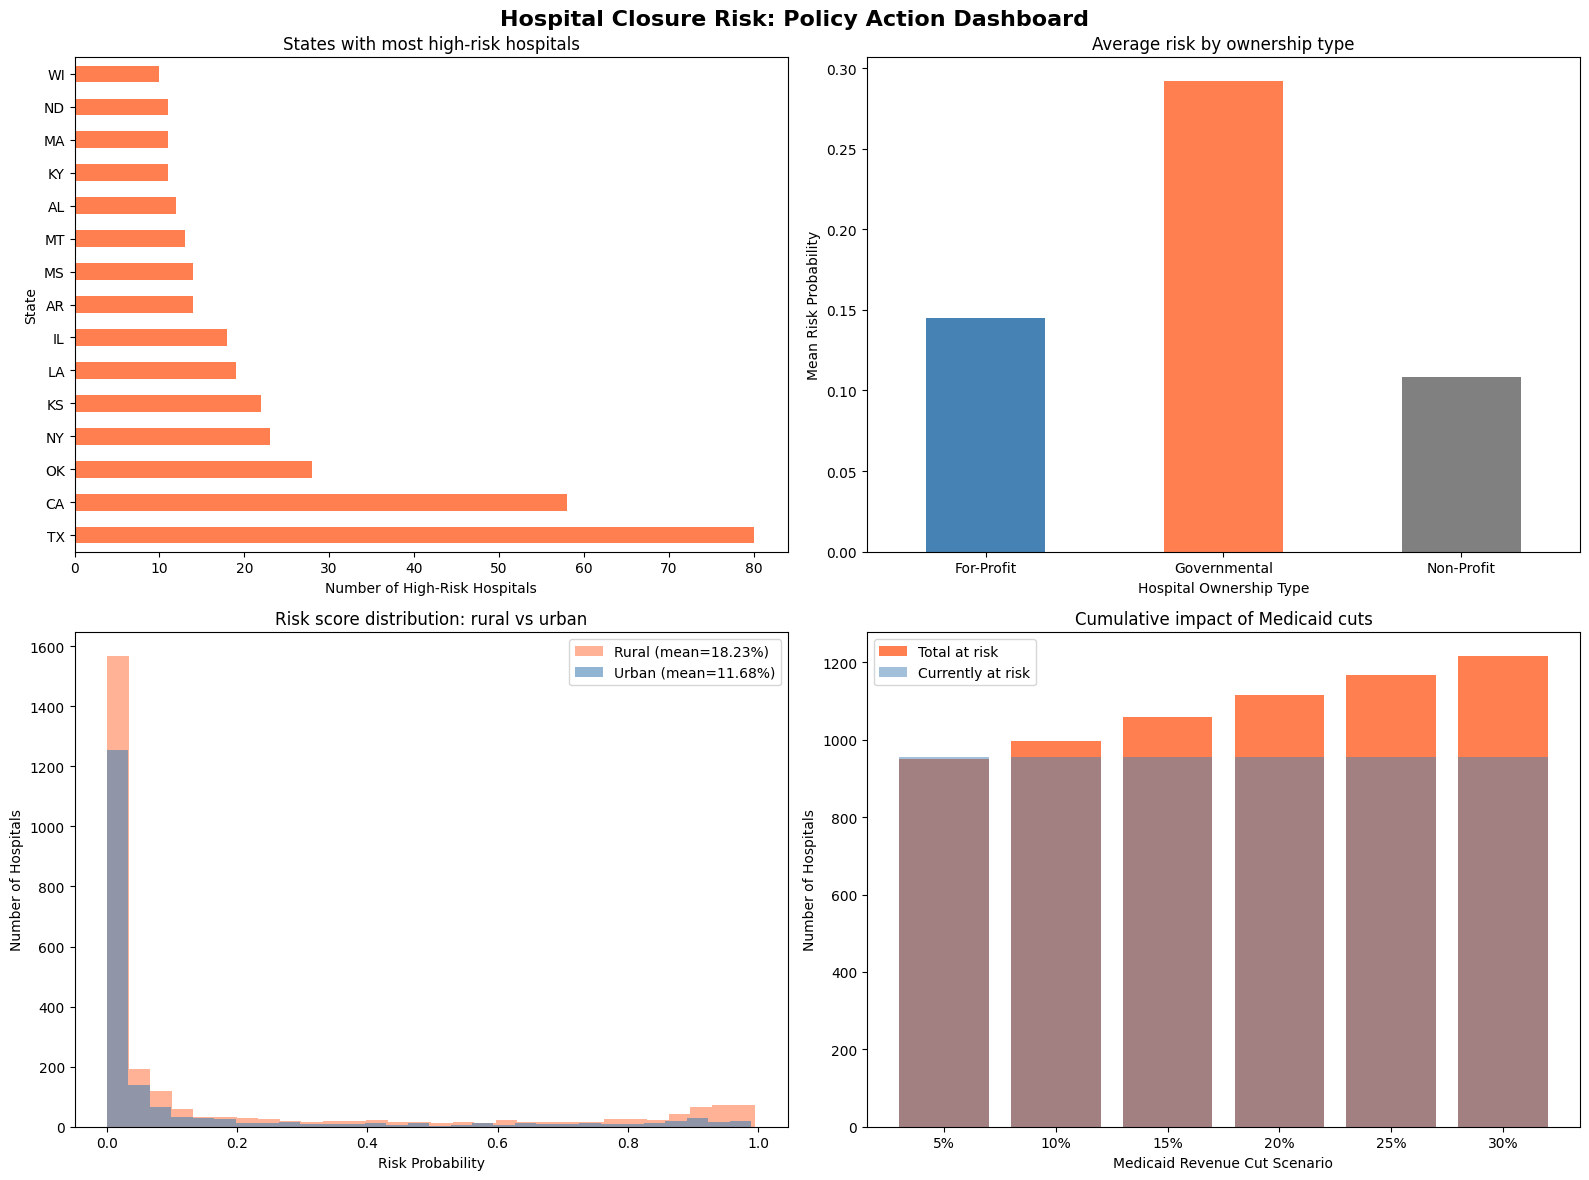

In [52]:
#Policy recommendation visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hospital Closure Risk: Policy Action Dashboard',
             fontsize=16, fontweight='bold')

#1.Risk distribution by state (top 15)
ax = axes[0, 0]
top15 = hosp.groupby('State')['Is_High_Risk'].sum().nlargest(15)
top15.plot(kind='barh', ax=ax, color='coral')
ax.set_title('States with most high-risk hospitals')
ax.set_xlabel('Number of High-Risk Hospitals')

#2.Risk by hospital type
ax = axes[0, 1]
type_risk = hosp.groupby('Hospital Ownership Type')['Risk_Probability'].mean()
type_risk.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'gray'])
ax.set_title('Average risk by ownership type')
ax.set_ylabel('Mean Risk Probability')
ax.tick_params(axis='x', rotation=0)

#3.Rural vs Urban risk comparison
ax = axes[1, 0]
rural_risk = hosp[hosp['Is_Rural']==1]['Risk_Probability']
urban_risk = hosp[hosp['Is_Urban']==1]['Risk_Probability']
ax.hist(rural_risk, bins=30, alpha=0.6, label=f'Rural (mean={rural_risk.mean():.2%})', color='coral')
ax.hist(urban_risk, bins=30, alpha=0.6, label=f'Urban (mean={urban_risk.mean():.2%})', color='steelblue')
ax.set_title('Risk score distribution: rural vs urban')
ax.set_xlabel('Risk Probability')
ax.set_ylabel('Number of Hospitals')
ax.legend()

#4.Scenario impact summary
ax = axes[1, 1]
scenario_labels = [f"{int(r['Cut Pct']*100)}%" for _, r in results_df.iterrows()]
scenario_newly = results_df['Newly At Risk'].values
scenario_existing = baseline_negative
bars = ax.bar(scenario_labels, results_df['Total Negative Margin'],
              color='coral', label='Total at risk')
ax.bar(scenario_labels, [baseline_negative]*len(scenario_labels),
       color='steelblue', alpha=0.5, label='Currently at risk')
ax.set_title('Cumulative impact of Medicaid cuts')
ax.set_xlabel('Medicaid Revenue Cut Scenario')
ax.set_ylabel('Number of Hospitals')
ax.legend()

plt.tight_layout()
plt.show()



Saved: table15_recommendations.png


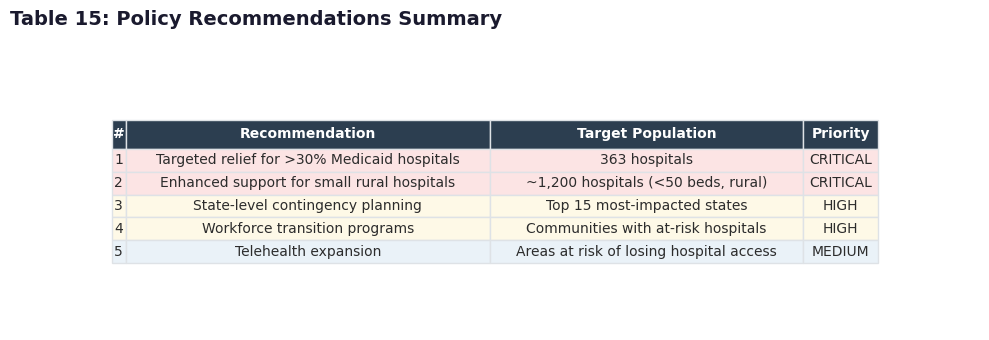

In [22]:
make_pro_table(
    title='Table 15: Policy Recommendations Summary',
    col_labels=['#', 'Recommendation', 'Target Population', 'Priority'],
    data=[
        ['1', 'Targeted relief for >30% Medicaid hospitals', '363 hospitals', 'CRITICAL'],
        ['2', 'Enhanced support for small rural hospitals', '~1,200 hospitals (<50 beds, rural)', 'CRITICAL'],
        ['3', 'State-level contingency planning', 'Top 15 most-impacted states', 'HIGH'],
        ['4', 'Workforce transition programs', 'Communities with at-risk hospitals', 'HIGH'],
        ['5', 'Telehealth expansion', 'Areas at risk of losing hospital access', 'MEDIUM'],
    ],
    highlight_col=3,
    highlight_rules=[(0, '#e74c3c')],
    row_colors=['#fce4e4', '#fce4e4', '#fef9e7', '#fef9e7', '#eaf2f8'],
    filename='table15_recommendations.png'
)

In [59]:
#Save the full risk report
risk_report.to_csv('hospital_risk_report.csv', index=False)
print("Saved: hospital_risk_report.csv")

#Save scenario analysis
results_df.to_csv('scenario_analysis.csv', index=False)
print("Saved: scenario_analysis.csv")

#Save state-level impact
state_impact.to_csv('state_impact_analysis.csv', index=False)
print("Saved: state_impact_analysis.csv")

#Download all files
files.download('hospital_risk_report.csv')
files.download('scenario_analysis.csv')
files.download('state_impact_analysis.csv')



Saved: hospital_risk_report.csv
Saved: scenario_analysis.csv
Saved: state_impact_analysis.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
print("=" * 65)
print("   HOSPITAL CLOSURE RISK PREDICTION — PROJECT SUMMARY")
print("=" * 65)
print(f"""
DATASET: NASHP Hospital Cost Tool 2020-2024
  - {hosp['CCN#'].nunique():,} hospitals across {hosp['State'].nunique()} states
  - 121 financial, operational, and structural variables
  - 5 years of longitudinal data (2020-2024)
  - 217 hospitals disappeared from the dataset (actual closures/mergers)

MODEL: {model_name}
  - Trained on {len(X_train):,} hospitals, tested on {len(X_test):,}
  - ROC AUC: {roc_auc_score(y_test, best_prob):.3f}
  - {len(feature_columns)} features across 4 categories:
    financial health, Medicaid vulnerability, structure, and trends

KEY FINDINGS:
  1. {baseline_negative:,} hospitals ({baseline_negative/baseline_total:.0%}) already have negative margins
  2. A 20% Medicaid revenue cut would push {results_df[results_df['Cut Pct']==0.20]['Newly At Risk'].values[0]:,.0f}
     additional hospitals into negative margins
  3. Rural hospitals face 2x the closure risk of urban hospitals
  4. Top risk factors: {', '.join(feat_imp.tail(5).index.tolist()[::-1])}

POLICY IMPLICATIONS:
  - The OBBBA's ~$1 trillion Medicaid cut over 10 years will
    disproportionately impact rural and small hospitals
  - The $50B Rural Health Transformation Fund covers only a
    fraction of projected losses
  - States with high Medicaid expansion enrollment face the
    largest coverage losses
  - Hospital closures create cascading effects: job losses,
    longer emergency response times, and reduced access to
    care for entire communities

RECOMMENDATIONS:
  1. Targeted relief for hospitals with >30% Medicaid dependence
  2. Enhanced support for rural and critical access hospitals
  3. State-level planning for service consolidation vs. closure
  4. Workforce transition programs for affected communities
  5. Telehealth investment to maintain access in areas losing
     physical hospital presence
""")

   HOSPITAL CLOSURE RISK PREDICTION — PROJECT SUMMARY

DATASET: NASHP Hospital Cost Tool 2020-2024
  - 4,468 hospitals across 51 states
  - 121 financial, operational, and structural variables
  - 5 years of longitudinal data (2020-2024)
  - 217 hospitals disappeared from the dataset (actual closures/mergers)
 
MODEL: Random Forest
  - Trained on 3,574 hospitals, tested on 894
  - ROC AUC: 0.991
  - 20 features across 4 categories:
    financial health, Medicaid vulnerability, structure, and trends
 
KEY FINDINGS:
  1. 956 hospitals (22%) already have negative margins
  2. A 20% Medicaid revenue cut would push 214
     additional hospitals into negative margins
  3. Rural hospitals face 2x the closure risk of urban hospitals
  4. Top risk factors: Operating Profit Margin, Cost_Revenue_Ratio, Commercial_Subsidy_Capacity, Margin_Trend, Net Profit Margin
 
POLICY IMPLICATIONS:
  - The OBBBA's ~$1 trillion Medicaid cut over 10 years will
    disproportionately impact rural and small hospit